# Week 2 – Day 2: Feature Selection, Data Splitting & Evaluation Setup

## 1) Introduction
Day 2 focus: **define `X` and `y` -> split data -> avoid leakage -> select features -> run baseline regression checks**.

Learning objectives:
- understand why feature selection matters
- understand why train/test split matters
- understand data leakage and how pipelines prevent it
- understand why cross-validation gives more stable estimates

## 2) Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression, RFE, SequentialFeatureSelector
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline

`train_test_split` splits data, `KFold/cross_val_score` run CV, `SelectKBest/RFE/SFS` perform feature selection, and `Lasso/Ridge` are embedded regularized methods.

### Shared dataset helper
To keep all three days connected, we use the same dataset path and generation logic.
- Day 1 creates and saves the dataset.
- Day 2 and Day 3 load it and regenerate it only if missing.


In [2]:
from pathlib import Path

def find_repo_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd] + list(cwd.parents):
        if (candidate / "requirements.txt").exists() and (candidate / "data").exists():
            return candidate
    return cwd

REPO_ROOT = find_repo_root()
DATASET_PATH = REPO_ROOT / "data" / "week2" / "house_energy_week2_sample.csv"
DATASET_PATH.parent.mkdir(parents=True, exist_ok=True)

def create_house_energy_dataset(path, n_rows=150, seed=42):
    import numpy as np
    import pandas as pd

    rng = np.random.default_rng(seed)
    house_size_m2 = np.clip(rng.normal(135, 48, n_rows), 40, 460)
    bedrooms = np.clip(np.round(house_size_m2 / 35 + rng.normal(0, 1, n_rows)), 1, 8).astype(int)
    building_age_years = np.clip(rng.normal(32, 22, n_rows), 1, 120)
    city = rng.choice(["Berlin", "Munich", "Hamburg", "Cologne", "Leipzig"], size=n_rows, p=[0.25, 0.2, 0.2, 0.2, 0.15])
    heating_type = rng.choice(["Gas", "Electric", "Heat Pump", "District"], size=n_rows, p=[0.4, 0.25, 0.2, 0.15])
    insulation_grade = rng.choice(["A", "B", "C", "D"], size=n_rows, p=[0.2, 0.35, 0.3, 0.15])
    average_temperature_c = np.clip(rng.normal(10.5, 5, n_rows), -8, 24)

    insulation_effect = pd.Series(insulation_grade).map({"A": -1300, "B": -650, "C": 200, "D": 1050}).to_numpy()
    heating_effect = pd.Series(heating_type).map({"Heat Pump": -900, "District": -300, "Gas": 220, "Electric": 520}).to_numpy()
    city_effect = pd.Series(city).map({"Berlin": 120, "Munich": 270, "Hamburg": 170, "Cologne": 100, "Leipzig": -40}).to_numpy()
    noise = rng.normal(0, 450, n_rows)

    energy_consumption_kwh = (
        3500
        + 23 * house_size_m2
        + 15 * building_age_years
        + (14 - average_temperature_c) * 175
        + insulation_effect
        + heating_effect
        + city_effect
        + noise
    )
    energy_consumption_kwh = np.clip(energy_consumption_kwh, 1500, None)

    df = pd.DataFrame({
        "house_size_m2": house_size_m2.round(1),
        "bedrooms": bedrooms,
        "building_age_years": building_age_years.round(1),
        "city": city,
        "heating_type": heating_type,
        "insulation_grade": insulation_grade,
        "average_temperature_c": average_temperature_c.round(1),
        "energy_consumption_kwh": energy_consumption_kwh.round(1),
    })

    for col in ["house_size_m2", "building_age_years", "average_temperature_c"]:
        idx = rng.choice(df.index, size=6, replace=False)
        df.loc[idx, col] = np.nan
    for col in ["city", "heating_type", "insulation_grade"]:
        idx = rng.choice(df.index, size=4, replace=False)
        df.loc[idx, col] = np.nan

    df.loc[4, ["house_size_m2", "energy_consumption_kwh"]] = [520, 35000]
    df.loc[58, ["building_age_years", "energy_consumption_kwh"]] = [145, 29000]
    df.loc[97, ["average_temperature_c", "energy_consumption_kwh"]] = [-20, 30500]

    duplicates = df.iloc[[12, 35]].copy()
    df = pd.concat([df, duplicates], ignore_index=True)
    df.to_csv(path, index=False)
    return df


## 3) Load dataset

In [3]:
if not DATASET_PATH.exists():
    _ = create_house_energy_dataset(DATASET_PATH, n_rows=150, seed=42)

df = pd.read_csv(DATASET_PATH)
display(df.head())
print(df.shape)
df.info()
display(df.describe())

,house_size_m2,bedrooms,building_age_years,city,heating_type,insulation_grade,average_temperature_c,energy_consumption_kwh
0,149.6,4,70.0,Hamburg,Gas,C,8.3,9320.4
1,85.1,1,1.0,Munich,Heat Pump,B,-2.0,7355.9
2,171.0,3,51.0,Hamburg,Electric,C,2.0,11496.9
3,180.1,5,24.8,Berlin,District,C,NaN,8946.7
4,520.0,1,30.7,Berlin,Electric,C,7.7,35000.0


(152, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   house_size_m2           146 non-null    float64
 1   bedrooms                152 non-null    int64  
 2   building_age_years      146 non-null    float64
 3   city                    148 non-null    object 
 4   heating_type            147 non-null    object 
 5   insulation_grade        148 non-null    object 
 6   average_temperature_c   146 non-null    float64
 7   energy_consumption_kwh  152 non-null    float64
dtypes: float64(4), int64(1), object(3)
memory usage: 9.6+ KB


,house_size_m2,bedrooms,building_age_years,average_temperature_c,energy_consumption_kwh
count,146.000000,152.000000,146.000000,146.000000,152.000000
mean,137.023288,3.822368,34.206164,10.156164,8082.386842
std,51.498706,1.619836,22.566949,5.524628,3745.102240
min,40.000000,1.000000,1.000000,-20.000000,3606.100000
25%,104.625000,3.000000,17.300000,7.750000,6333.075000
50%,137.100000,4.000000,34.700000,10.700000,7506.350000
75%,164.225000,5.000000,49.575000,13.250000,8714.500000
max,520.000000,8.000000,145.000000,21.700000,35000.000000


## 4) Define supervised task
Target is continuous (`energy_consumption_kwh`), so this is regression in a supervised setup.

In [4]:
target = 'energy_consumption_kwh'
X = df.drop(columns=[target])
y = df[target]

## 5) Feature groups

In [5]:
numerical_features = ['house_size_m2','bedrooms','building_age_years','average_temperature_c']
categorical_features = ['city','heating_type','insulation_grade']
print(numerical_features)
print(categorical_features)

['house_size_m2', 'bedrooms', 'building_age_years', 'average_temperature_c']
['city', 'heating_type', 'insulation_grade']


## 6) Train-test split

`train_test_split()` separates the data into training data and testing data.

- `test_size=0.2` means 20% of the rows are held out for testing.
- `random_state=42` makes the random split reproducible.

We fit preprocessing and feature-selection steps using the training data only, then use the test data as a final unseen check.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(121, 7) (31, 7)


## 7) Data leakage warning

Data leakage happens when information that would not be available in a real prediction situation accidentally enters training.

Examples include scaling before splitting, imputing missing values using the full dataset, or creating a feature from the target. Leakage can make model performance look much better than it really is.


## 8) Preprocessing pipeline

We build preprocessing as a reusable scikit-learn workflow.

- `SimpleImputer(strategy='median')` fills missing numeric values with the median.
- `SimpleImputer(strategy='most_frequent')` fills missing categorical values with the most common category.
- `StandardScaler()` standardizes numeric columns.
- `OneHotEncoder(handle_unknown='ignore')` converts categories to 0/1 columns and safely handles new categories in test data.
- `ColumnTransformer()` applies different preprocessing to numeric and categorical columns.
- `Pipeline()` chains steps so each step is fitted on training data only.


In [7]:
numerical_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer([('num', numerical_pipeline, numerical_features), ('cat', categorical_pipeline, categorical_features)])

## 9) Baseline model

`LinearRegression()` fits a straight-line relationship between features and the numeric target.

The baseline gives us a simple reference point before we try feature-selection methods. Day 2 uses only a light performance check because the main focus is selecting features and setting up validation correctly.


In [8]:
baseline = Pipeline([('preprocessor', preprocessor), ('model', LinearRegression())])
baseline.fit(X_train, y_train)
y_pred = baseline.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(mae, rmse, r2)

1529.5194732338268 1971.3121138440276 -0.25180565841691505


## 10) Correlation filter

A correlation filter is a simple filter method. It checks each numeric feature separately and measures the strength of its linear relationship with the target.

High absolute correlation can be useful, but correlation does not prove causation and may miss non-linear relationships.


,corr,abs_corr
house_size_m2,0.484233,0.484233
average_temperature_c,-0.468876,0.468876
building_age_years,0.280683,0.280683
bedrooms,0.070785,0.070785


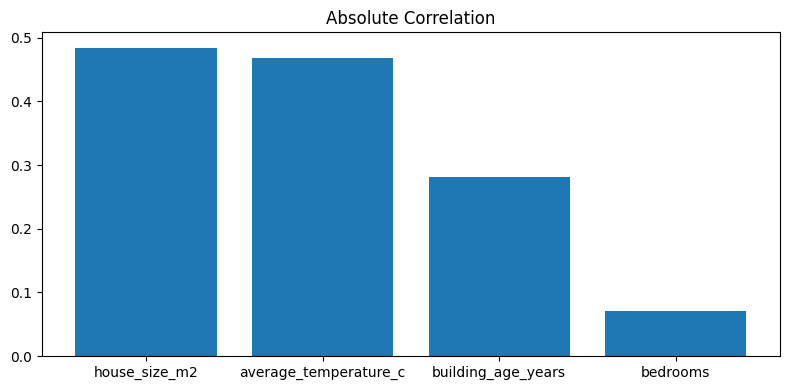

In [9]:
corr_df = df[numerical_features + [target]].copy().fillna(df[numerical_features + [target]].median(numeric_only=True))
corr = corr_df.corr()[target].drop(target)
abs_corr = corr.abs().sort_values(ascending=False)
display(pd.DataFrame({'corr': corr, 'abs_corr': corr.abs()}).sort_values('abs_corr', ascending=False))
plt.figure(figsize=(8,4)); plt.bar(abs_corr.index, abs_corr.values); plt.title('Absolute Correlation'); plt.tight_layout(); plt.show()

## 11) SelectKBest + f_regression

`SelectKBest(score_func=..., k=...)` ranks individual features and keeps the top `k`.

Here `score_func=f_regression` scores each feature using a linear regression relationship with the target. `k=3` means we select the three highest-scoring processed features.


In [10]:
X_train_processed = preprocessor.fit_transform(X_train)

def get_feature_names(prep):
    names = []
    for name, transformer, cols in prep.transformers_:
        if hasattr(transformer, 'named_steps'):
            last = list(transformer.named_steps.values())[-1]
            if hasattr(last, 'get_feature_names_out'):
                names.extend(last.get_feature_names_out(cols))
            else:
                names.extend(cols)
    return names

feature_names = get_feature_names(preprocessor)
skb = SelectKBest(score_func=f_regression, k=3)
skb.fit(X_train_processed, y_train)
skb_df = pd.DataFrame({'feature': feature_names, 'score': skb.scores_}).sort_values('score', ascending=False)
display(skb_df.head(15))
selected_skb = skb_df.head(3)['feature'].tolist()

,feature,score
0,house_size_m2,37.432599
3,average_temperature_c,37.049227
10,heating_type_Electric,15.786569
2,building_age_years,9.850679
13,insulation_grade_A,6.906256
16,insulation_grade_D,3.657403
4,city_Berlin,3.137916
12,heating_type_Heat Pump,2.935429
6,city_Hamburg,1.482898
15,insulation_grade_C,1.430412


## 12) Mutual Information

`mutual_info_regression` is another filter method. It can capture more general dependency between a feature and a numeric target, including some non-linear patterns.

The score is useful for ranking features, but it should still be interpreted with domain knowledge and validation.


,feature,mi
6,city_Hamburg,0.117637
1,bedrooms,0.101651
3,average_temperature_c,0.095958
15,insulation_grade_C,0.071105
16,insulation_grade_D,0.064979
8,city_Munich,0.063324
14,insulation_grade_B,0.059094
13,insulation_grade_A,0.047029
0,house_size_m2,0.039877
7,city_Leipzig,0.020536


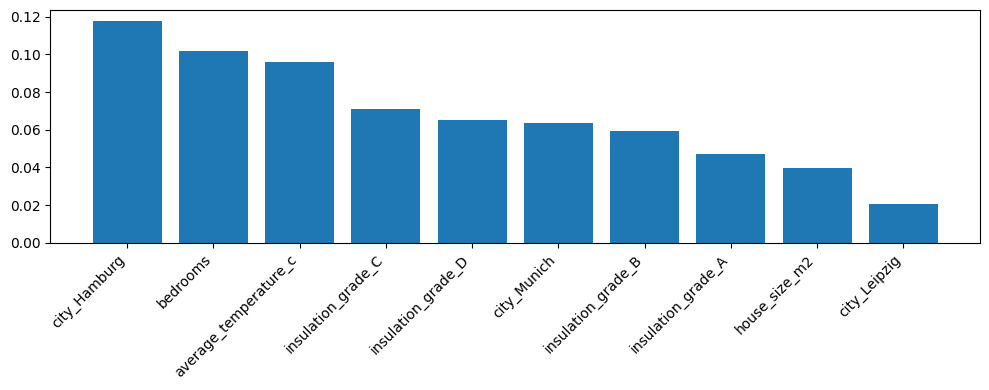

In [11]:
mi = mutual_info_regression(X_train_processed, y_train, random_state=42)
mi_df = pd.DataFrame({'feature': feature_names, 'mi': mi}).sort_values('mi', ascending=False)
display(mi_df.head(15))
plt.figure(figsize=(10,4)); plt.bar(mi_df.head(10)['feature'], mi_df.head(10)['mi']); plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()
selected_mi = mi_df.head(3)['feature'].tolist()

## 13) RFE

`RFE(estimator=..., n_features_to_select=...)` means recursive feature elimination.

It fits the estimator, removes weaker features, and repeats until the requested number remains. Here `estimator=LinearRegression()` supplies the model used for ranking, and `n_features_to_select=3` keeps three processed features.


In [12]:
rfe = RFE(estimator=LinearRegression(), n_features_to_select=3)
rfe.fit(X_train_processed, y_train)
rfe_selected = [n for n, k in zip(feature_names, rfe.support_) if k]
print(rfe_selected)

['house_size_m2', 'heating_type_Electric', 'insulation_grade_D']


## 14) Forward Feature Selection

`SequentialFeatureSelector(...)` is a wrapper method. It evaluates feature subsets by repeatedly fitting a model.

With `direction='forward'`, it starts with no features and adds one feature at a time. `cv=5` evaluates choices using five-fold cross-validation.


In [13]:
sfs = SequentialFeatureSelector(LinearRegression(), n_features_to_select=3, direction='forward', scoring='neg_mean_squared_error', cv=5)
sfs.fit(X_train_processed, y_train)
forward_selected = [n for n, k in zip(feature_names, sfs.get_support()) if k]
print(forward_selected)

['average_temperature_c', 'heating_type_Electric', 'insulation_grade_D']

## 15) Lasso

`Lasso(alpha=..., max_iter=...)` is an embedded method because feature selection happens while the model is fitted.

`alpha` controls the strength of L1 regularization. Larger values shrink more coefficients toward zero, and some may become exactly zero. `max_iter=10000` gives the optimizer enough iterations to converge.


In [14]:
lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_train_processed, y_train)
lasso_df = pd.DataFrame({'feature': feature_names, 'lasso_coef': lasso.coef_}).sort_values('lasso_coef', key=np.abs, ascending=False)
display(lasso_df.head(15))

,feature,lasso_coef
10,heating_type_Electric,2952.716552
16,insulation_grade_D,2312.782253
0,house_size_m2,2241.003207
3,average_temperature_c,-1783.297321
2,building_age_years,1054.536399
7,city_Leipzig,790.134829
13,insulation_grade_A,-757.645806
12,heating_type_Heat Pump,-727.164904
1,bedrooms,-704.024812
9,heating_type_District,-481.520656


## 16) Ridge

`Ridge(alpha=...)` uses L2 regularization. It shrinks coefficients but usually does not set them exactly to zero.

Ridge is useful when features are correlated or when we want a more stable linear model.


In [15]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_processed, y_train)
ridge_df = pd.DataFrame({'feature': feature_names, 'ridge_coef': ridge.coef_}).sort_values('ridge_coef', key=np.abs, ascending=False)
display(ridge_df.head(15))

,feature,ridge_coef
10,heating_type_Electric,2352.126265
0,house_size_m2,2217.490344
16,insulation_grade_D,1866.657563
3,average_temperature_c,-1770.323343
12,heating_type_Heat Pump,-1170.011495
13,insulation_grade_A,-1073.655682
2,building_age_years,1043.613041
9,heating_type_District,-927.779824
7,city_Leipzig,711.197107
1,bedrooms,-689.149035


## 17) Optional tree-based feature importance

`RandomForestRegressor(random_state=...)` trains many decision trees and averages their predictions. `random_state=42` makes the random parts reproducible.

Tree-based feature importance can reveal useful non-linear signals, but it is still an estimate and should be checked with validation.


,feature,importance
0,house_size_m2,0.376852
3,average_temperature_c,0.325868
2,building_age_years,0.236388
16,insulation_grade_D,0.013197
13,insulation_grade_A,0.011186
1,bedrooms,0.006191
12,heating_type_Heat Pump,0.005680
14,insulation_grade_B,0.003832
15,insulation_grade_C,0.003522
4,city_Berlin,0.003048


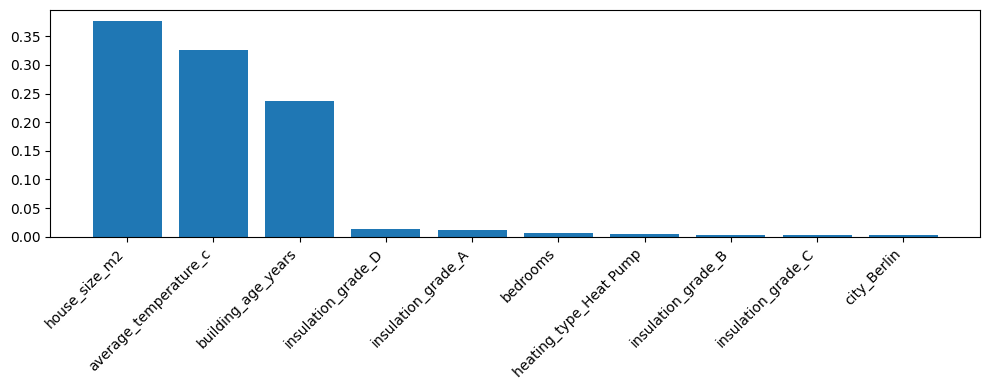

In [16]:
rf = RandomForestRegressor(random_state=42, n_estimators=200)
rf.fit(X_train_processed, y_train)
rf_df = pd.DataFrame({'feature': feature_names, 'importance': rf.feature_importances_}).sort_values('importance', ascending=False)
display(rf_df.head(15))
plt.figure(figsize=(10,4)); plt.bar(rf_df.head(10)['feature'], rf_df.head(10)['importance']); plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

## 18) Cross-validation

`KFold(n_splits=5, shuffle=True, random_state=42)` creates five train/validation splits. `shuffle=True` mixes the rows before splitting, and `random_state=42` makes the folds reproducible.

`cross_val_score(scoring=...)` fits and scores the pipeline on each fold. We use RMSE, so lower values are better. Some scikit-learn versions use `neg_root_mean_squared_error`; if unavailable, we calculate RMSE as the square root of MSE.


In [17]:
cv_model = Pipeline([('preprocessor', preprocessor), ('model', LinearRegression())])
kf = KFold(n_splits=5, shuffle=True, random_state=42)
try:
    scores = cross_val_score(cv_model, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
    rmse_scores = -scores
except ValueError:
    scores = cross_val_score(cv_model, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-scores)
print(np.round(rmse_scores, 2), round(rmse_scores.mean(), 2), round(rmse_scores.std(), 2))

[5202.46 1889.49 2242.25 4301.92 3697.05] 3466.64 1245.02


## 19) Summary table (feature-selection setup comparison)

In [18]:
summary = pd.DataFrame([
    ['Correlation', 'Linear relation', 'Correlations', 'Quick numeric screening'],
    ['Mutual Information', 'Dependency incl. non-linear', 'MI scores', 'Potential non-linear effects'],
    ['RFE', 'Remove weakest iteratively', 'Subset + ranking', 'Model-based subset search'],
    ['Forward Selection', 'Add strongest step-by-step', 'Selected subset', 'Greedy subset building'],
    ['Lasso', 'L1 regularization', 'Sparse coefficients', 'Feature shrinking'],
    ['Ridge', 'L2 regularization', 'Shrunk coefficients', 'Stability'],
    ['Random Forest Importance', 'Tree importance', 'Importance scores', 'Non-linear relationships']
], columns=['Method', 'Main idea', 'Output', 'When useful'])
display(summary)

,Method,Main idea,Output,When useful
0,Correlation,Linear relation,Correlations,Quick numeric screening
1,Mutual Information,Dependency incl. non-linear,MI scores,Potential non-linear effects
2,RFE,Remove weakest iteratively,Subset + ranking,Model-based subset search
3,Forward Selection,Add strongest step-by-step,Selected subset,Greedy subset building
4,Lasso,L1 regularization,Sparse coefficients,Feature shrinking
5,Ridge,L2 regularization,Shrunk coefficients,Stability
6,Random Forest Importance,Tree importance,Importance scores,Non-linear relationships


In [19]:
print('Week 2 Day 2 feature selection and splitting practical completed successfully.')

Week 2 Day 2 feature selection and splitting practical completed successfully.


## Student Code Challenges

These questions are not only for answering in text. You should change the code, rerun the cell, compare the output, and explain what changed.

The cells in this final section are exercises. They are intentionally left unexecuted so students can run them during or after the practical session.


### Challenge 1 - Change the train/test split

**Question:**  
What happens if we use 30% of the data for testing instead of 20%?

**Code:**


In [ ]:
# TODO: Change test_size from 0.2 to 0.3.
# TODO: Rerun the split and baseline model.
# TODO: Compare train/test sizes and model performance.


**Reflection:**  
Write 2-3 sentences comparing the data sizes and model performance.


### Challenge 2 - Change the number of selected features in SelectKBest

**Question:**  
Which features are selected if `k` changes from 3 to 5?

**Code:**


In [ ]:
# TODO: Change SelectKBest from k=3 to k=5.
# TODO: Rerun feature selection.
# TODO: Compare which features are selected.


**Reflection:**  
Write 2-3 sentences explaining which features were added or removed.


### Challenge 3 - Change RFE selected features

**Question:**  
Which features are selected if RFE keeps 5 features instead of 3?

**Code:**


In [ ]:
# TODO: Change RFE from n_features_to_select=3 to n_features_to_select=5.
# TODO: Rerun RFE.
# TODO: Compare the selected feature names.


**Reflection:**  
Write 2-3 sentences comparing the smaller and larger RFE feature sets.


### Challenge 4 - Change Lasso alpha

**Question:**  
How does alpha affect the number of coefficients that become zero?

**Code:**


In [ ]:
# TODO: Try Lasso alpha values 0.01, 0.1, and 1.0.
# TODO: Count how many coefficients become zero.
# TODO: Explain what happens as alpha changes.


**Reflection:**  
Write 2-3 sentences explaining what changed as alpha increased.


### Challenge 5 - Change cross-validation folds

**Question:**  
What changes if we use 10 folds instead of 5?

**Code:**


In [ ]:
# TODO: Change KFold from n_splits=5 to n_splits=10.
# TODO: Rerun cross-validation.
# TODO: Compare mean RMSE and standard deviation.


**Reflection:**  
Write 2-3 sentences comparing the five-fold and ten-fold results.
